# Import libaries

In [2]:
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

# 0. Load data

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "jp797498e/twitter-entity-sentiment-analysis",
    output_dir="data"
)

DATA_DIR = Path("data")

TRAIN_FILE = DATA_DIR / "twitter_training.csv"
VALIDATION_FILE = DATA_DIR / "twitter_validation.csv"

print(f"Training dataset: {TRAIN_FILE}")
print(f"Validation dataset: {VALIDATION_FILE}")

Training dataset: data\twitter_training.csv
Validation dataset: data\twitter_validation.csv


# 1. Data inspection

In [25]:
# Add the names of the columns in train and validation data frame
train_df = pd.read_csv(
    TRAIN_FILE,
    header=None,
    names=["id", "entity", "sentiment", "text"]
)

validation_df = pd.read_csv(
    VALIDATION_FILE,
    header=None,
    names=["id", "entity", "sentiment", "text"]
)

print("=" * 50)
print("DATA INSPECTION")
print("=" * 50)

# Dataset shape
print("\nTraining shape:", train_df.shape)
print("Validation shape:", validation_df.shape)

# Column information
print("\n" + "-" * 50)
print("COLUMN INFORMATION")
print("-" * 50)

column_info = pd.DataFrame({
    "Column": train_df.columns,
    "Data Type": train_df.dtypes.astype(str).values
})

print(f"\n{column_info}")

# Missing values
print("\n" + "-" * 50)
print("MISSING VALUES")
print("-" * 50)

print("\nTrain:")
missing_values_train = train_df.isnull().sum()

if missing_values_train.sum() == 0:
    print("No missing values found.")
else:
    print(missing_values_train[missing_values_train > 0])

print("\nValidation:")
missing_values_val = validation_df.isnull().sum()

if missing_values_val.sum() == 0:
    print("No missing values found.")
else:
    print(missing_values_val[missing_values_val > 0])

# Duplicates
print("\n" + "-" * 50)
print("DUPLICATE ROWS")
print("-" * 50)

print("\nTrain:")
print(f"Number of duplicate rows: {train_df.duplicated().sum()}")

print("\nValidation:")
print(f"Number of duplicate rows: {validation_df.duplicated().sum()}")

print("\n" + "=" * 50)
print("INSPECTION COMPLETE")
print("=" * 50)

DATA INSPECTION

Training shape: (74682, 4)
Validation shape: (1000, 4)

--------------------------------------------------
COLUMN INFORMATION
--------------------------------------------------

      Column Data Type
0         id     int64
1     entity       str
2  sentiment       str
3       text       str

--------------------------------------------------
MISSING VALUES
--------------------------------------------------

Train:
text    686
dtype: int64

Validation:
No missing values found.

--------------------------------------------------
DUPLICATE ROWS
--------------------------------------------------

Train:
Number of duplicate rows: 2700

Validation:
Number of duplicate rows: 0

INSPECTION COMPLETE


## 1.1 Inspect missing values

In [30]:
train_df[train_df["text"].isna()].head(10)

,id,entity,sentiment,text
61,2411,Borderlands,Neutral,NaN
553,2496,Borderlands,Neutral,NaN
589,2503,Borderlands,Neutral,NaN
745,2532,Borderlands,Positive,NaN
1105,2595,Borderlands,Positive,NaN
1106,2595,Borderlands,Positive,NaN
2295,1602,CallOfDutyBlackopsColdWar,Irrelevant,NaN
2296,1602,CallOfDutyBlackopsColdWar,Irrelevant,NaN
2297,1602,CallOfDutyBlackopsColdWar,Irrelevant,NaN
2359,1613,CallOfDutyBlackopsColdWar,Irrelevant,NaN


### Info
There are **684** tweets with missing text, so they do not provide any useful information for the model. We will remove them later during the data cleaning stage.

## 1.2 Inspect duplicates

In [29]:
train_df[train_df.duplicated(keep=False)].sort_values("text").head(10)

,id,entity,sentiment,text
51507,10441,RedDeadRedemption(RDR),Negative,. . . Check out this clip! CGalvSports strea...
51504,10441,RedDeadRedemption(RDR),Negative,. . . Check out this clip! CGalvSports strea...
23580,4442,Google,Neutral,. - Android 9.0. . - Bezel-Less screen. . - D...
23583,4442,Google,Neutral,. - Android 9.0. . - Bezel-Less screen. . - D...
42270,10052,PlayerUnknownsBattlegrounds(PUBG),Neutral,. . pic.twitter.com/P1A5IeWDOa
42273,10052,PlayerUnknownsBattlegrounds(PUBG),Neutral,. . pic.twitter.com/P1A5IeWDOa
42096,10023,PlayerUnknownsBattlegrounds(PUBG),Negative,. . “No More Chicken Dinner: Why PUBG Ban in...
42099,10023,PlayerUnknownsBattlegrounds(PUBG),Negative,. . “No More Chicken Dinner: Why PUBG Ban in...
41832,1578,Battlefield,Positive,. . Exciting announcement in a few hours fami...
41835,1578,Battlefield,Positive,. . Exciting announcement in a few hours fami...


### Info
There are **2,700** duplicate tweets in the dataset. Since they do not provide additional information, we will remove them later during the data cleaning stage.

# 2. Evaluate data analysis
- Sentiment distribution
- Entity distribution
- Text length
- Sample tweets

## 2.1 Sentiment distribution

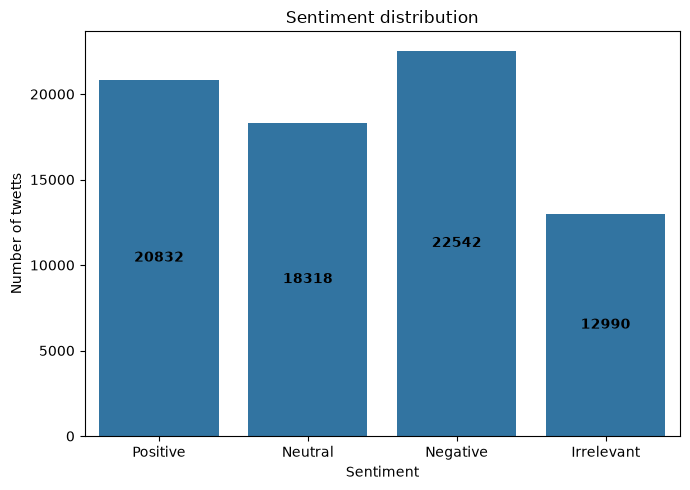

In [40]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=train_df,
    x="sentiment"
)

ax.bar_label(
    ax.containers[0],
    label_type="center",
    fontweight="bold"
)

plt.title("Sentiment distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of twetts")

plt.tight_layout()
plt.show()

### Observation
The sentiment classes are relatively well balanced. **Positive, Negative, and Neutral** contain a similar number of tweets, while **Irrelevant** is less frequent. However, the difference is not large enough to indicate a severe class imbalance problem.

## 2.2 Entity distribution

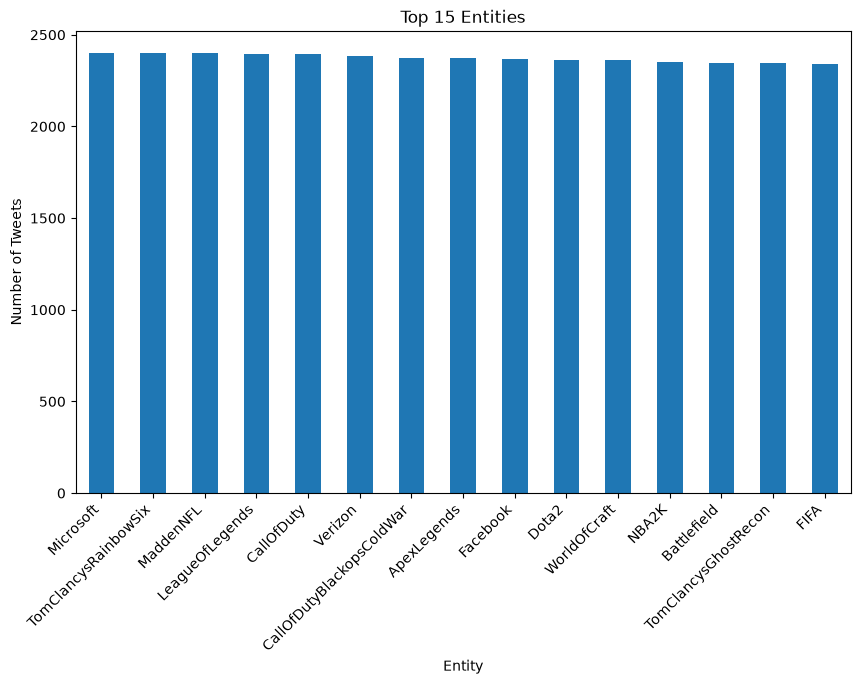

In [53]:
plt.figure(figsize=(10, 6))

train_df["entity"].value_counts().head(15).plot(kind="bar")

plt.title("Top 15 Entities")
plt.xlabel("Entity")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45, ha="right")
plt.show()

### Observation
There are **almost no significant differences in the number of tweets across entities**, indicating that the dataset is relatively well balanced in terms of entity representation.

## 2.3 Text length

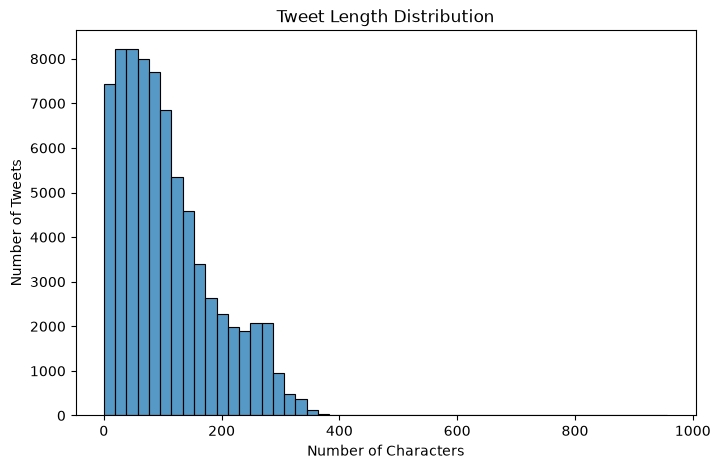

mean    107.78
std      79.84
min       0.00
max     957.00
Name: text_length, dtype: float64

In [62]:
train_df["text_length"] = train_df["text"].fillna("").str.len()

plt.figure(figsize=(8, 5))

sns.histplot(
    data=train_df,
    x="text_length",
    bins=50
)

plt.title("Tweet Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Tweets")
plt.show()

train_df["text_length"].describe()
train_df["text_length"].agg(["mean", "std", "min", "max"]).round(2)

### Observation
Tweets have an average length of **108 characters**, but their lengths vary considerably. Most tweets are relatively short, although some significantly longer texts are present, with the maximum length reaching **957 characters**.

## 2.4 Sample tweets

In [64]:
for sentiment in train_df["sentiment"].unique():
    print(f"\n--- {sentiment} ---")
    display(
        train_df[train_df["sentiment"] == sentiment][
            ["entity", "text"]
        ].head(3)
    )


--- Positive ---


,entity,text
0,Borderlands,im getting on borderlands and i will murder yo...
1,Borderlands,I am coming to the borders and I will kill you...
2,Borderlands,im getting on borderlands and i will kill you ...



--- Neutral ---


,entity,text
12,Borderlands,"Rock-Hard La Varlope, RARE & POWERFUL, HANDSOM..."
13,Borderlands,"Rock-Hard La Varlope, RARE & POWERFUL, HANDSOM..."
14,Borderlands,"Rock-Hard La Varlope, RARE & POWERFUL, HANDSOM..."



--- Negative ---


,entity,text
24,Borderlands,the biggest dissappoinment in my life came out...
25,Borderlands,The biggest disappointment of my life came a y...
26,Borderlands,The biggest disappointment of my life came a y...



--- Irrelevant ---


,entity,text
102,Borderlands,Appreciate the (sonic) concepts / praxis Valen...
103,Borderlands,Appreciate the (sound) concepts / practices th...
104,Borderlands,Evaluate the (sound) concepts / concepts of Va...
